### Simple Linear Regression
**Simple linear regression** is a statistical method used to model and understand the relationship between **two continuous variables:**
- One **independent variable** (predictor) -> usually called **X**
- One **dependent variable** (outcome) -> usually called **Y**

The goal is to find a straight line that best describes how changes in X are associated with changes in Y.


#### The basic equation:
$
Y = \beta_0 + \beta_1X + \varepsilon
$

Where:
- **$\beta_0$ (intercept)** -> value of Y when X = 0
- **$\beta_1$ (slope)** -> how much Y changes for each 1-unit increase in X
- **$\varepsilon$ (error term)** -> random variation not explained by X

#### What does the model does:
Simple linear regression:
- Estimates the **best-fitting** line through data points
- Minimizes the **sum of squared errors** (distances from points to the line)
- Allows **prediction** and **inference**

#### Loss Function:
Simple linear regression uses **Mean Squared Error (MSE)** as its loss function.
$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$

#### Why Squared Error?
- Prevents positive and negative errors from canceling out
- Penalizes large errors more heavily
- Makes the function smooth and differentiable (good for optimization)

#### When to Use:
- Relationship roughly linear
- Single feature

#### Assumptions:
- Linearity
- No extreme outliers
- Homoscedasticity


### Simple Example

In [3]:
from sklearn.linear_model import LinearRegression

X = [[1], [2], [3], [4]]
y = [30, 40, 55, 70]

model = LinearRegression()
model.fit(X, y)

print(model.coef_)
print(model.intercept_)

[13.5]
15.000000000000007


In [4]:
model.predict([[5]])

array([82.5])

### Use Case
#### Predicting Delivery Time Based on Distance
##### Business Problem:
A logistics company wants to **estimate delivery time (minutes)** based only on **distance (km)** for quick ETA shown to users.
```python
Distance (X) -> Delivery Time (y)
```

##### Why Simple Linear Regression Fits:
- Single dominant factor: distance
- Relationship roughly linear
- Fast inference
- Easy to explain to business


In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
df = pd.read_csv("data/delivery_time_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (100000, 2)


,distance_km,delivery_time_min
0,19.04,65.49
1,47.56,157.78
2,36.73,114.80
3,30.13,86.61
4,8.22,35.37


In [10]:
# Feature and Target

X = df[["distance_km"]]
y = df["delivery_time_min"]

In [11]:
# Train-test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
# Fit Linear Regression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
# Model Parameters

intercept = model.intercept_
slope = model.coef_[0]

print("Model Equation:")
print(f"Delivery_Time = {intercept:.2f} + {slope:.2f} * Distance")

Model Equation:
Delivery_Time = 5.03 + 3.00 * Distance


In [22]:
# Prediction

y_pred = model.predict(X_test)

In [23]:
# Evaluation

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"MAE : {mae:.2f} minutes")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R^2 : {r2:.4f}")

Model Performance:
MAE : 3.19 minutes
RMSE : 4.00 minutes
R^2 : 0.9913


In [26]:
# New Prediction Example

new_distance = [[10]]
predicted_time = model.predict(new_distance)

print(f"\nPredicted Delivery Time for 10 km: {predicted_time[0]:.2f} minutes")


Predicted Delivery Time for 10 km: 35.02 minutes


/Users/jatinrokde/CodeBase/SynapseWorks/MLForge/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [27]:
import matplotlib.pyplot as plt

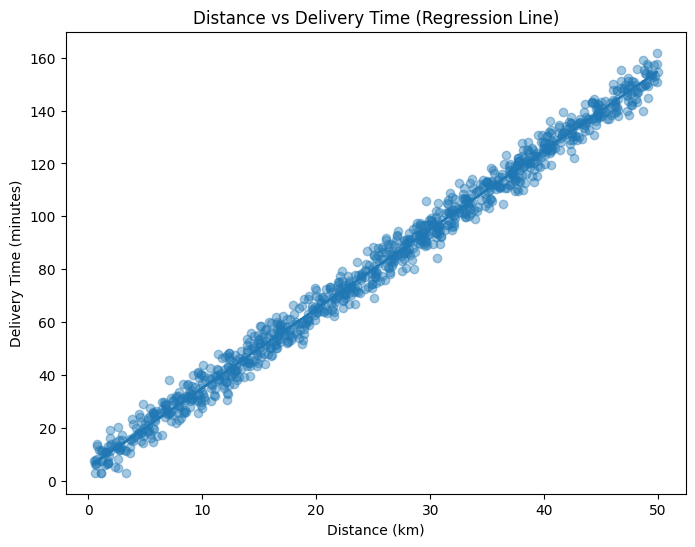

In [28]:
# Small Sample for Visualization

sample = df.sample(1000, random_state=42)

X_sample = sample[["distance_km"]]
y_sample = sample["delivery_time_min"]

y_pred_sample = model.predict(X_sample)

plt.figure(figsize=(8,6))
plt.scatter(X_sample, y_sample, alpha=0.4)
plt.plot(X_sample, y_pred_sample)
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.title("Distance vs Delivery Time (Regression Line)")
plt.show()

##### Saving Model using joblib

In [ ]:
import os
import joblib

os.makedirs("project-simple_linear_regression", exist_ok=True)

model_path = os.path.join("project-simple_linear_regression", "delivery_time_model.pkl")
joblib.dump(model, model_path)
print("Model Saved!")

Model Saved!
